In [1]:
!git clone https://github.com/karolpiczak/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 21.03 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [2]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

### 1. Upload do Dataset

In [3]:
caminho_csv = 'ESC-50/meta/esc50.csv'
PASTA_AUDIO = 'ESC-50/audio/'

In [4]:
df_original = pd.read_csv(caminho_csv)

Categorias
Animais (Índices 0 a 9)
0: Dog / 1: Rooster / 2: Pig / 3: Cow / 4: Frog / 5: Cat / 6: Hen / 7: Insects (flying) / 8: Sheep / 9: Crow

 Paisagens Naturais e Sons de Água (Índices 10 a 19)
 10: Rain / 11: Sea waves / 12: Crackling fire / 13: Crickets / 14: Chirping birds / 15: Water drops / 16: Wind / 17: Pouring water / 18: Toilet flush (Descarga de vaso sanitário) / 19: Thunderstorm (Tempestade com trovoada)

 Ruídos Externos / Urbanos (Índices 40 a 49)
 40: Helicopter / 41: Chainsaw / 42: Siren / 43: Car horn / 44: Engine / 45: Train / 46: Church bells / 47: Airplane / 48: Fireworks / 49: Hand saw

In [5]:
df = df_original[(df_original['target'] <= 19) | (df_original['target'] >= 40)]

In [6]:
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
5,1-101296-B-19.wav,1,19,thunderstorm,False,101296,B
8,1-103298-A-9.wav,1,9,crow,False,103298,A


In [7]:
df.shape

(1200, 7)

### 2. Ajustes do Dataset

In [8]:
SR = 16000
COLUNA_ARQUIVO = "filename"

In [9]:
def estatisticas(vetor, prefixo):
    """
    Transforma uma série temporal em características por áudio.
    """
    vetor = np.asarray(vetor).flatten()

    return {
        f"{prefixo}_mean": np.mean(vetor),
        f"{prefixo}_std": np.std(vetor),
        f"{prefixo}_median": np.median(vetor),
        f"{prefixo}_min": np.min(vetor),
        f"{prefixo}_max": np.max(vetor),
    }

### 3. Experimento A: ATRIBUTOS ACÚSTICOS CLÁSSICOS

In [10]:
# MFCC
# Delta
# Delta-Delta
# ZCR
# Spectral Centroid
# ============================================================

def extrair_experimento_A(caminho, sr=SR, n_mfcc=13):

    y, sr = librosa.load(caminho, sr=sr, mono=True)

    features = {}

    # --------------------------------------------------------
    # 1. MFCC
    # --------------------------------------------------------

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc
    )

    for i in range(n_mfcc):
        features.update(
            estatisticas(
                mfcc[i],
                f"mfcc_{i+1}"
            )
        )

    # --------------------------------------------------------
    # 2. DELTA
    # --------------------------------------------------------

    delta = librosa.feature.delta(mfcc)

    for i in range(n_mfcc):
        features.update(
            estatisticas(
                delta[i],
                f"delta_{i+1}"
            )
        )

    # --------------------------------------------------------
    # 3. DELTA-DELTA
    # --------------------------------------------------------

    delta_delta = librosa.feature.delta(
        mfcc,
        order=2
    )

    for i in range(n_mfcc):
        features.update(
            estatisticas(
                delta_delta[i],
                f"delta_delta_{i+1}"
            )
        )

    # --------------------------------------------------------
    # 4. ZERO CROSSING RATE
    # --------------------------------------------------------

    zcr = librosa.feature.zero_crossing_rate(y)[0]

    features.update(
        estatisticas(
            zcr,
            "zcr"
        )
    )

    # --------------------------------------------------------
    # 5. SPECTRAL CENTROID
    # --------------------------------------------------------

    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )[0]

    features.update(
        estatisticas(
            centroid,
            "centroid"
        )
    )

    return features

### 4. Experimento B: ATRIBUTOS INTERPRETÁVEIS

In [11]:
# Frequência dominante
# Pulsos/s
# Silêncio
# Entropia
# Fluxo espectral

def extrair_experimento_B(caminho, sr=SR):

    y, sr = librosa.load(caminho, sr=sr, mono=True)

    features = {}

    # --------------------------------------------------------
    # 1. FREQUÊNCIA DOMINANTE
    # --------------------------------------------------------

    espectro = np.abs(
        librosa.stft(y)
    )

    frequencias = librosa.fft_frequencies(
        sr=sr
    )

    indice_dominante = np.argmax(
        espectro,
        axis=0
    )

    freq_dominante = frequencias[
        indice_dominante
    ]

    features.update(
        estatisticas(
            freq_dominante,
            "freq_dominante"
        )
    )

    # --------------------------------------------------------
    # 2. PULSOS POR SEGUNDO
    #
    # Usa onset detection.
    # Cada onset representa aproximadamente um evento/pulso.
    # --------------------------------------------------------

    onset_frames = librosa.onset.onset_detect(
        y=y,
        sr=sr
    )

    duracao = librosa.get_duration(
        y=y,
        sr=sr
    )

    if duracao > 0:
        pulsos_por_segundo = len(onset_frames) / duracao
    else:
        pulsos_por_segundo = 0

    features["pulsos_por_segundo"] = pulsos_por_segundo

    # --------------------------------------------------------
    # 3. SILÊNCIO
    #
    # Percentual de frames considerados silenciosos.
    # --------------------------------------------------------

    rms = librosa.feature.rms(y=y)[0]

    threshold = np.max(rms) * 0.05

    frames_silenciosos = rms < threshold

    percentual_silencio = np.mean(
        frames_silenciosos
    )

    features["percentual_silencio"] = percentual_silencio

    # --------------------------------------------------------
    # 4. ENTROPIA ESPECTRAL
    #
    # Mede quão espalhada está a energia no espectro.
    # --------------------------------------------------------

    potencia = espectro ** 2

    soma = np.sum(
        potencia,
        axis=0,
        keepdims=True
    )

    # evita divisão por zero
    soma[soma == 0] = 1e-12

    probabilidade = potencia / soma

    entropia = entropy(
        probabilidade,
        axis=0
    )

    features.update(
        estatisticas(
            entropia,
            "entropia_espectral"
        )
    )

    # --------------------------------------------------------
    # 5. FLUXO ESPECTRAL
    # --------------------------------------------------------

    spectral_flux = librosa.onset.onset_strength(
        y=y,
        sr=sr
    )

    features.update(
        estatisticas(
            spectral_flux,
            "fluxo_espectral"
        )
    )

    return features

### 5. Experimento C: A + B

In [12]:
def extrair_experimento_C(caminho,  n_mfcc, sr=SR):

    y, sr = librosa.load(caminho, sr=sr, mono=True)

    features = {}

    # 1. MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc
    )
    for i in range(n_mfcc):
        features.update(
            estatisticas(
                mfcc[i],
                f"mfcc_{i+1}"
            )
        )

    # 2. DELTA
    delta = librosa.feature.delta(mfcc)
    for i in range(n_mfcc):
        features.update(
            estatisticas(
                delta[i],
                f"delta_{i+1}"
            )
        )

    # 3. DELTA-DELTA
    delta_delta = librosa.feature.delta(
        mfcc,
        order=2
    )
    for i in range(n_mfcc):
        features.update(
            estatisticas(
                delta_delta[i],
                f"delta_delta_{i+1}"
            )
        )

    # 4. ZERO CROSSING RATE
    zcr = librosa.feature.zero_crossing_rate(y)[0]

    features.update(
        estatisticas(
            zcr,
            "zcr"
        )
    )

    # 5. SPECTRAL CENTROID
    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )[0]
    features.update(
        estatisticas(
            centroid,
            "centroid"
        )
    )


    # 6. FREQUÊNCIA DOMINANTE
    espectro = np.abs(librosa.stft(y))
    frequencias = librosa.fft_frequencies(sr=sr)
    indice_dominante = np.argmax(
        espectro,
        axis=0
    )
    freq_dominante = frequencias[indice_dominante]
    features.update(estatisticas(freq_dominante, "freq_dominante"))

    # 7. PULSOS POR SEGUNDO
    # Usa onset detection.
    # Cada onset representa aproximadamente um evento/pulso.
    onset_frames = librosa.onset.onset_detect(y=y,sr=sr)
    duracao = librosa.get_duration(y=y, sr=sr)
    if duracao > 0:
        pulsos_por_segundo = len(onset_frames) / duracao
    else:
        pulsos_por_segundo = 0

    features["pulsos_por_segundo"] = pulsos_por_segundo

    # 8. SILÊNCIO
    rms = librosa.feature.rms(y=y)[0]
    threshold = np.max(rms) * 0.05
    frames_silenciosos = rms < threshold
    percentual_silencio = np.mean(
        frames_silenciosos
    )
    features["percentual_silencio"] = percentual_silencio

    # 9. ENTROPIA ESPECTRAL
    potencia = espectro ** 2
    soma = np.sum(
        potencia,
        axis=0,
        keepdims=True
    )

    # evita divisão por zero
    soma[soma == 0] = 1e-12
    probabilidade = potencia / soma

    entropia = entropy(
        probabilidade,
        axis=0
    )
    features.update(
        estatisticas(
            entropia,
            "entropia_espectral"
        )
    )

    # 10. FLUXO ESPECTRAL
    spectral_flux = librosa.onset.onset_strength(
        y=y,
        sr=sr
    )

    features.update(
        estatisticas(
            spectral_flux,
            "fluxo_espectral"
        )
    )

    return features

### 6. Dataframes Finais Gerados

In [13]:
resultados_A = []
resultados_B = []
resultados_C = []

for _, linha in df.iterrows():

    arquivo = linha[COLUNA_ARQUIVO]

    caminho = f"{PASTA_AUDIO}/{arquivo}"

    try:

        features_A = extrair_experimento_A(caminho)
        features_B = extrair_experimento_B(caminho)
        features_C = extrair_experimento_C(caminho, 5)

        # --------------------------------------------
        # Metadados
        # --------------------------------------------

        features_A["filename"] = arquivo
        features_B["filename"] = arquivo
        features_C["filename"] = arquivo

        # mantém a classe original
        if "target" in df.columns:
            features_A["target"] = linha["target"]
            features_B["target"] = linha["target"]
            features_C["target"] = linha["target"]

        if "category" in df.columns:
            features_A["category"] = linha["category"]
            features_B["category"] = linha["category"]
            features_C["category"] = linha["category"]

        resultados_A.append(features_A)
        resultados_B.append(features_B)
        resultados_C.append(features_C)

    except Exception as e:

        print(
            f"Erro em {arquivo}: {e}"
        )

In [14]:
resultados_D = []

for _, linha in df.iterrows():

    arquivo = linha[COLUNA_ARQUIVO]

    caminho = f"{PASTA_AUDIO}/{arquivo}"

    try:
        features_D = extrair_experimento_C(caminho, 2)

        # --------------------------------------------
        # Metadados
        # --------------------------------------------

        features_D["filename"] = arquivo

        # mantém a classe original
        if "target" in df.columns:
            features_D["target"] = linha["target"]

        if "category" in df.columns:
            features_D["category"] = linha["category"]

        resultados_D.append(features_D)

    except Exception as e:

        print(
            f"Erro em {arquivo}: {e}"
        )

In [15]:
df_A = pd.DataFrame(resultados_A)
df_B = pd.DataFrame(resultados_B)
df_C = pd.DataFrame(resultados_C)

print("Experimento A:")
print(df_A.shape)

print("\nExperimento B:")
print(df_B.shape)

print("\nExperimento C:")
print(df_C.shape)

print("\nPrimeiras colunas A:")
print(df_A.columns.tolist())

print("\nColunas B:")
print(df_B.columns.tolist())

print("\nPrimeiras colunas C:")
print(df_C.columns.tolist())

Experimento A:
(1200, 208)

Experimento B:
(1200, 20)

Experimento C:
(1200, 105)

Primeiras colunas A:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_1_median', 'mfcc_1_min', 'mfcc_1_max', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_2_median', 'mfcc_2_min', 'mfcc_2_max', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_3_median', 'mfcc_3_min', 'mfcc_3_max', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_4_median', 'mfcc_4_min', 'mfcc_4_max', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_5_median', 'mfcc_5_min', 'mfcc_5_max', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_6_median', 'mfcc_6_min', 'mfcc_6_max', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_7_median', 'mfcc_7_min', 'mfcc_7_max', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_8_median', 'mfcc_8_min', 'mfcc_8_max', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_9_median', 'mfcc_9_min', 'mfcc_9_max', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_10_median', 'mfcc_10_min', 'mfcc_10_max', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_11_median', 'mfcc_11_min', 'mfcc_11_max', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_12_median', 'mfcc_12_min', 'mfcc_1

In [16]:
df_D = pd.DataFrame(resultados_D)

print("\nExperimento D:")
print(df_D.shape)
print("\nPrimeiras colunas D:")
print(df_D.columns.tolist())


Experimento D:
(1200, 60)

Primeiras colunas D:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_1_median', 'mfcc_1_min', 'mfcc_1_max', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_2_median', 'mfcc_2_min', 'mfcc_2_max', 'delta_1_mean', 'delta_1_std', 'delta_1_median', 'delta_1_min', 'delta_1_max', 'delta_2_mean', 'delta_2_std', 'delta_2_median', 'delta_2_min', 'delta_2_max', 'delta_delta_1_mean', 'delta_delta_1_std', 'delta_delta_1_median', 'delta_delta_1_min', 'delta_delta_1_max', 'delta_delta_2_mean', 'delta_delta_2_std', 'delta_delta_2_median', 'delta_delta_2_min', 'delta_delta_2_max', 'zcr_mean', 'zcr_std', 'zcr_median', 'zcr_min', 'zcr_max', 'centroid_mean', 'centroid_std', 'centroid_median', 'centroid_min', 'centroid_max', 'freq_dominante_mean', 'freq_dominante_std', 'freq_dominante_median', 'freq_dominante_min', 'freq_dominante_max', 'pulsos_por_segundo', 'percentual_silencio', 'entropia_espectral_mean', 'entropia_espectral_std', 'entropia_espectral_median', 'entropia_espectral_min', 'entropia_espect

### 6. Análise de Poder Discriminativo com ANOVA/F-Score
    -Quais características mais representam/diferenciam as classes?

In [17]:
# ANÁLISE DE PODER DISCRIMINATIVO

def analisar_atributos(df_features, coluna_classe="target"):

    # somente atributos numéricos
    X = df_features.select_dtypes(
        include=np.number
    ).copy()

    # remove a própria variável target
    if coluna_classe in X.columns:
        X = X.drop(columns=[coluna_classe])

    y = df_features[coluna_classe]

    # remove NaN / infinito
    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    mascara = X.notna().all(axis=1)
    X = X[mascara]
    y = y[mascara]

    # F-score ANOVA
    f_scores, p_values = f_classif(
        X,
        y
    )

    resultado = pd.DataFrame({
        "atributo": X.columns,
        "F_score": f_scores,
        "p_value": p_values
    })

    resultado = resultado.sort_values(
        "F_score",
        ascending=False
    )

    return resultado

In [18]:
ranking_A = analisar_atributos(
    df_A,
    "target"
)

ranking_B = analisar_atributos(
    df_B,
    "target"
)

ranking_C = analisar_atributos(
    df_C,
    "target"
)

print("----------EXPERIMENTO A----------")
display(ranking_A.head(20))

print("----------EXPERIMENTO B----------")
display(ranking_B)

print("----------EXPERIMENTO C----------")
display(ranking_C)

----------EXPERIMENTO A----------


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,atributo,F_score,p_value
131,delta_delta_1_std,65.841514,2.540666e-222
144,delta_delta_3_max,65.180125,9.329214e-221
133,delta_delta_1_min,58.227353,1.060066e-203
143,delta_delta_3_min,56.587080,1.658201e-199
13,mfcc_3_min,56.306830,8.773027e-199
79,delta_3_max,56.146008,2.286967e-198
66,delta_1_std,55.617239,5.397038e-197
141,delta_delta_3_std,53.883645,1.928958e-192
76,delta_3_std,53.562783,1.370714e-191
78,delta_3_min,52.497602,9.648903e-189


----------EXPERIMENTO B----------


,atributo,F_score,p_value
13,fluxo_espectral_std,65.294085,1.595527e-208
16,fluxo_espectral_max,55.077032,2.689387e-185
12,fluxo_espectral_mean,44.425947,3.551874e-158
11,entropia_espectral_max,27.314275,2.818519e-106
7,entropia_espectral_mean,24.411094,3.652464e-96
9,entropia_espectral_median,24.218123,1.780893e-95
14,fluxo_espectral_median,22.897491,1.034234e-90
4,freq_dominante_max,22.194626,3.891025e-88
1,freq_dominante_std,21.983636,2.337169e-87
6,percentual_silencio,19.868510,2.081590e-79


----------EXPERIMENTO C----------


,atributo,F_score,p_value
64,delta_delta_3_max,70.965678,1.953909e-220
51,delta_delta_1_std,69.052095,1.731995e-216
53,delta_delta_1_min,65.695961,2.174505e-209
98,fluxo_espectral_std,65.294085,1.595527e-208
61,delta_delta_3_std,63.541075,1.043872e-204
...,...,...,...
45,delta_5_mean,1.791433,6.465679e-03
72,delta_delta_5_median,1.565529,2.943010e-02
67,delta_delta_4_median,1.514282,4.040574e-02
40,delta_4_mean,0.798124,7.678253e-01


In [19]:
ranking_D = analisar_atributos(
    df_D,
    "target"
)
print("----------EXPERIMENTO D----------")
display(ranking_D)

----------EXPERIMENTO D----------


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [55] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,atributo,F_score,p_value
21,delta_delta_1_std,69.052095,1.731995e-216
23,delta_delta_1_min,65.695961,2.174505e-209
53,fluxo_espectral_std,65.294085,1.595527e-208
11,delta_1_std,58.539071,1.919329e-193
24,delta_delta_1_max,55.816707,4.610853e-187
56,fluxo_espectral_max,55.077032,2.689387e-185
13,delta_1_min,54.026525,9.162837e-183
39,centroid_max,50.314104,1.413447e-173
14,delta_1_max,49.055819,2.253539e-170
29,delta_delta_2_max,44.954867,1.326528e-159


### 7. Visualizando os atributos mais discriminativos

In [20]:
# ============================================================
# VISUALIZAR OS ATRIBUTOS MAIS DISCRIMINATIVOS
# ============================================================

def visualizar_top_atributos(
    df_features,
    ranking,
    coluna_classe="target",
    n=10
):

    top = ranking.head(n)["atributo"].tolist()

    for atributo in top:

        plt.figure(figsize=(12, 5))

        sns.boxplot(
            data=df_features,
            x=coluna_classe,
            y=atributo
        )

        plt.title(
            f"{atributo} — distribuição por classe"
        )

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

TOP A ---------


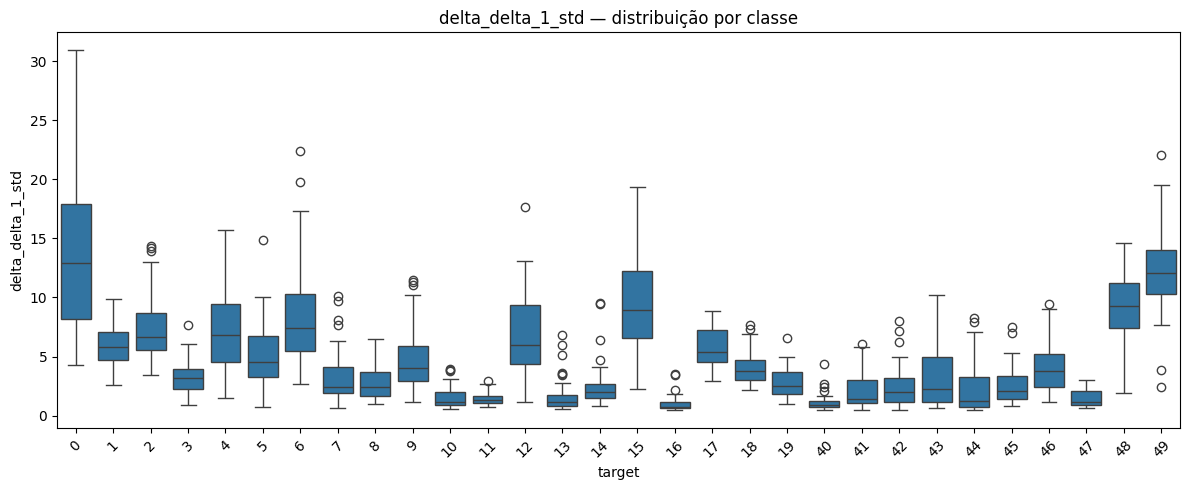

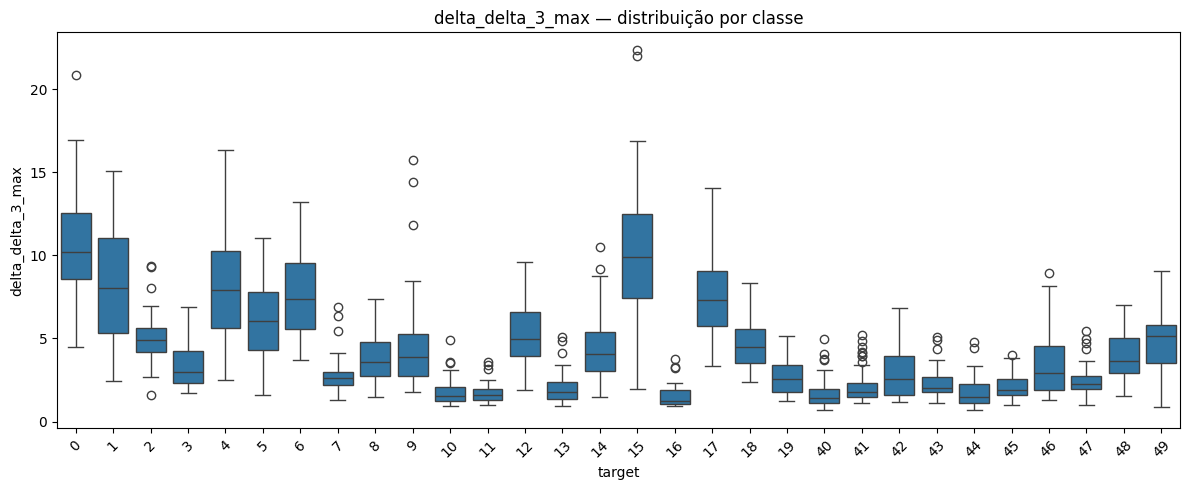

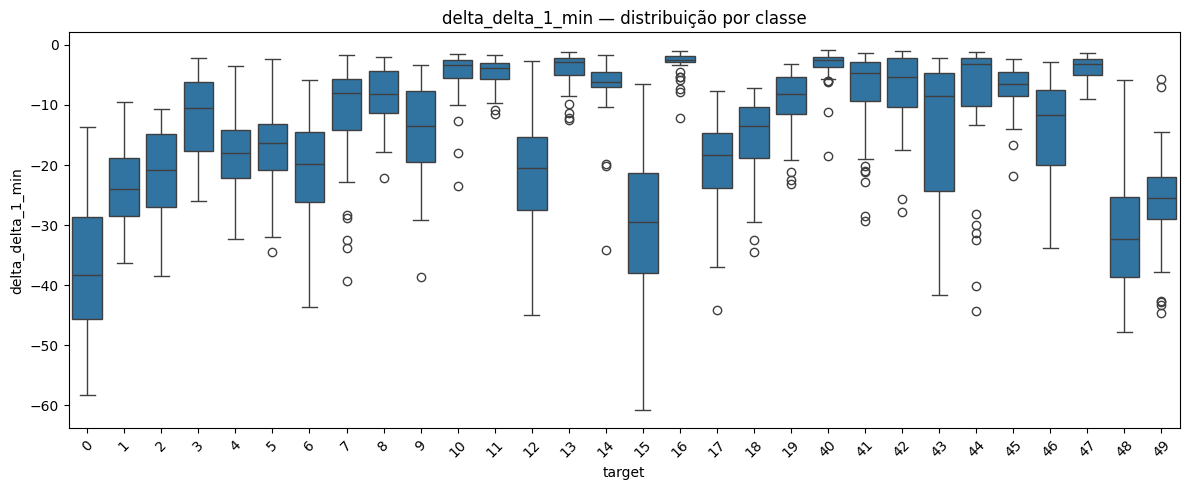

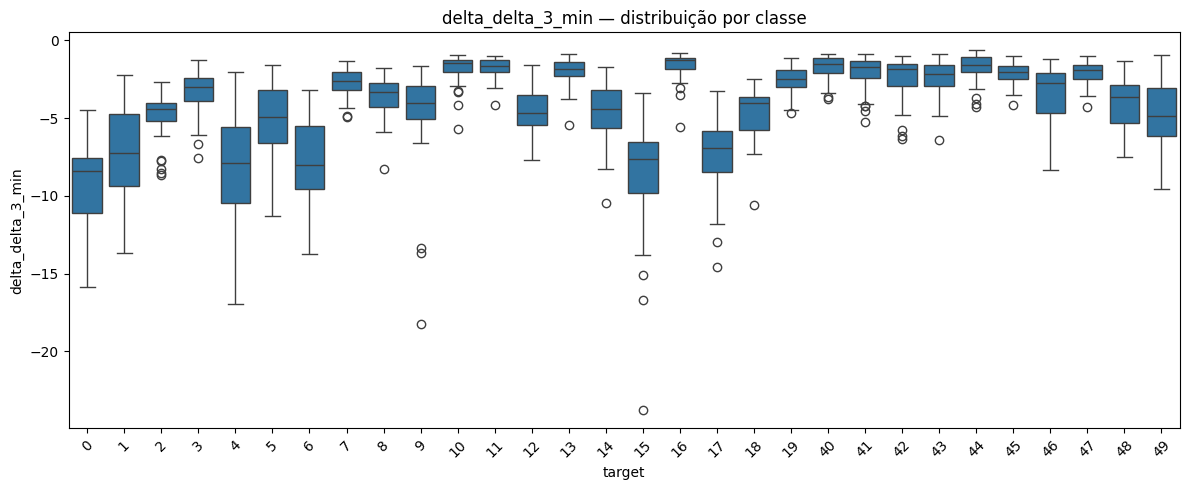

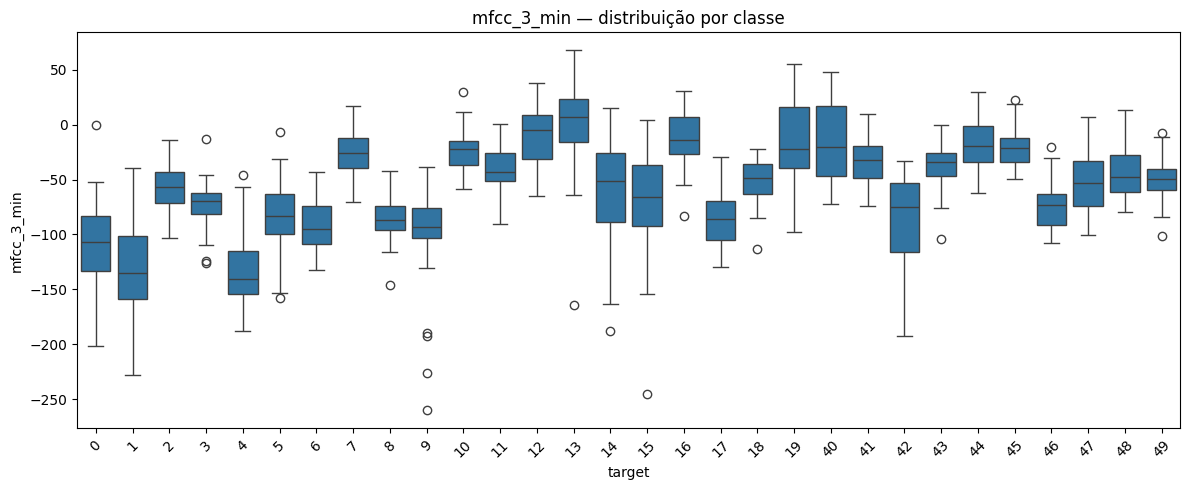

TOP B ---------


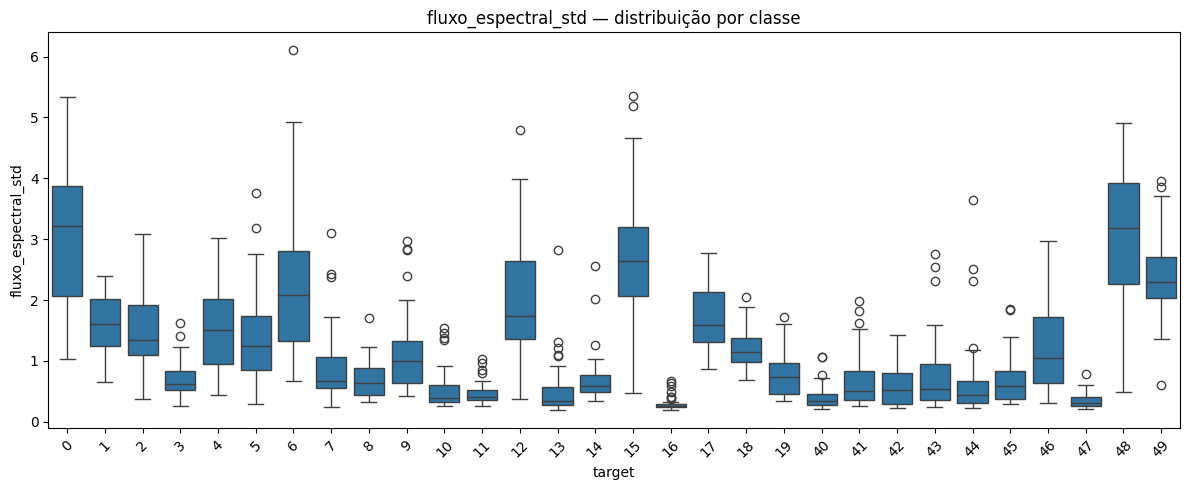

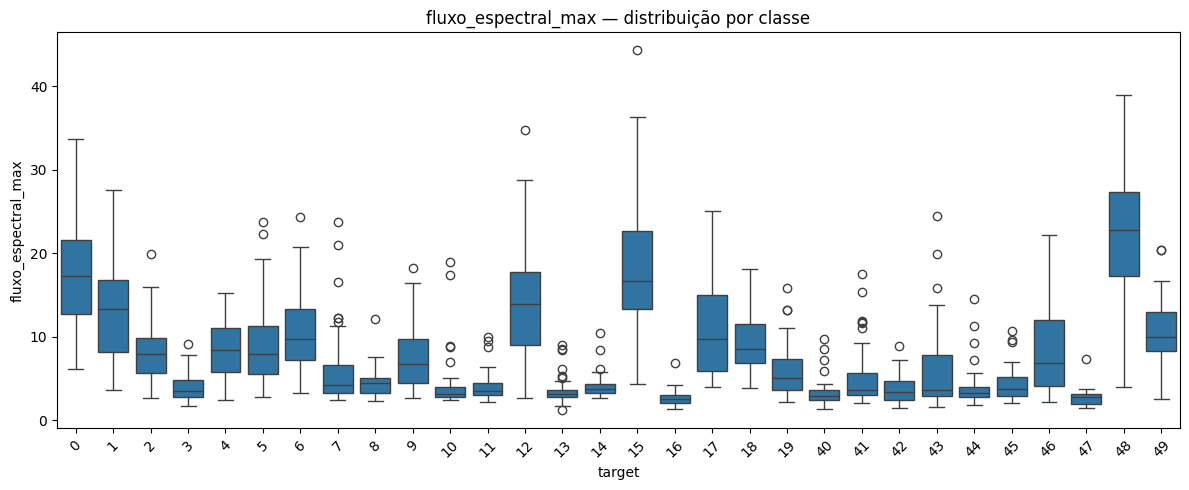

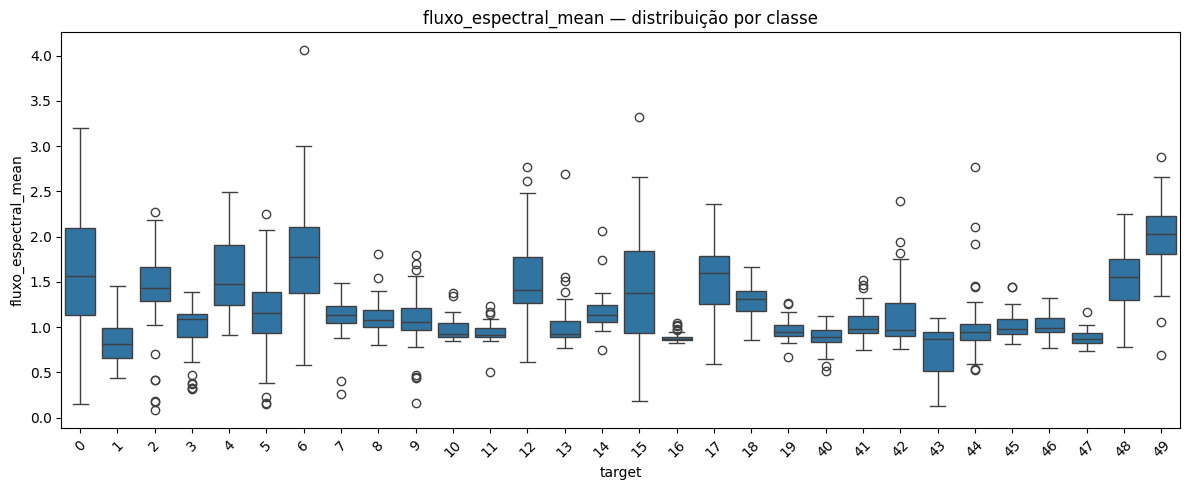

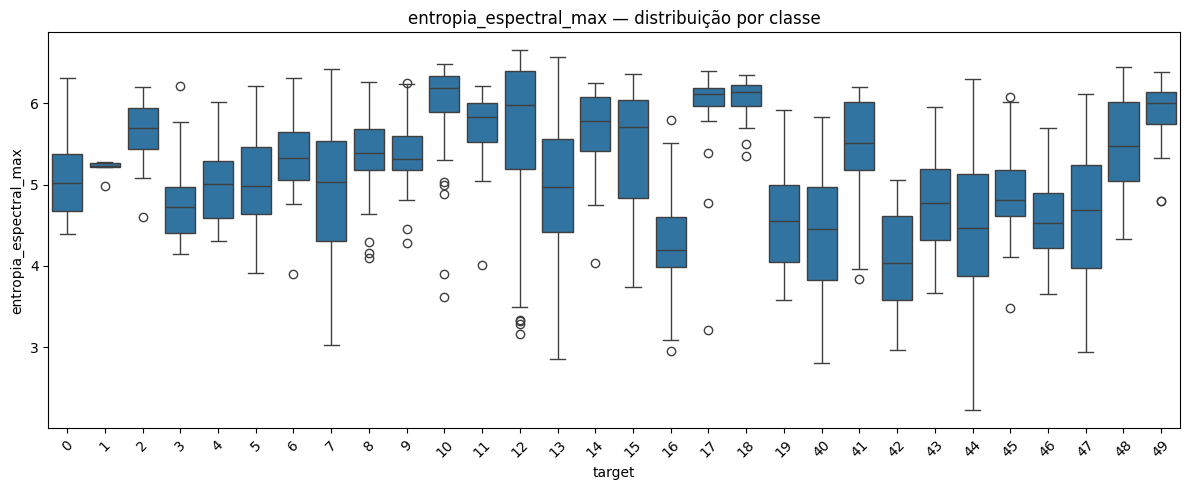

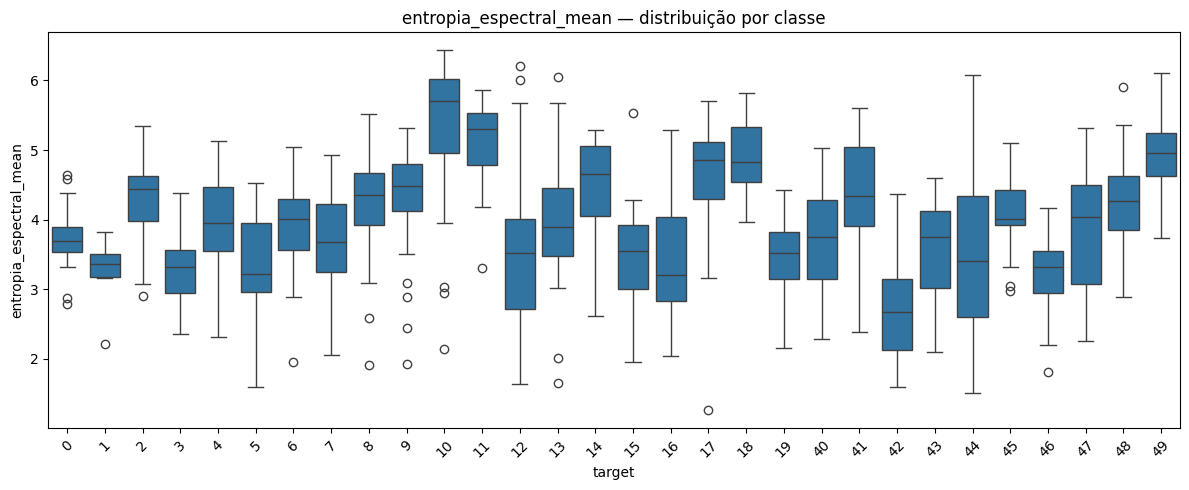

TOP C ---------


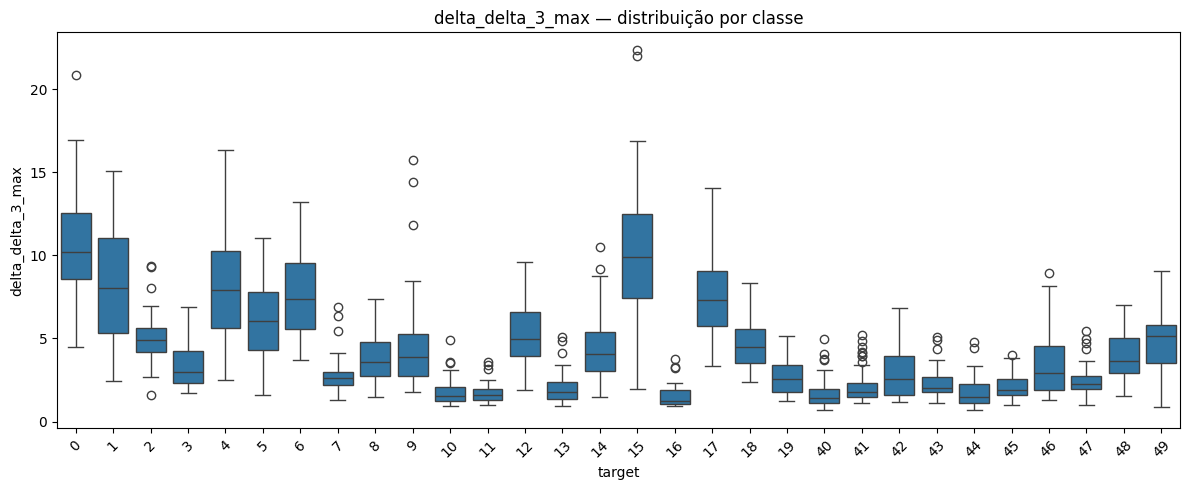

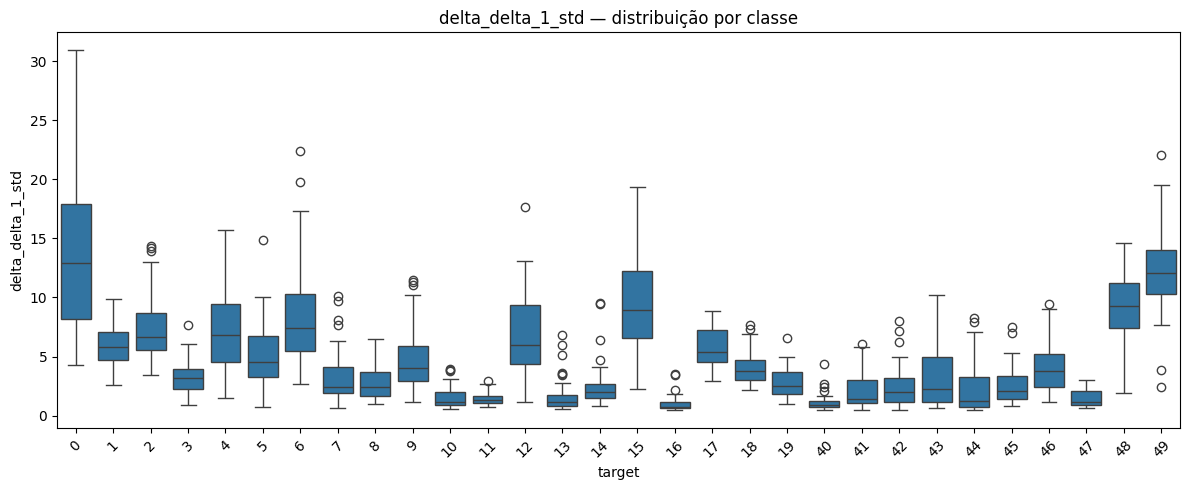

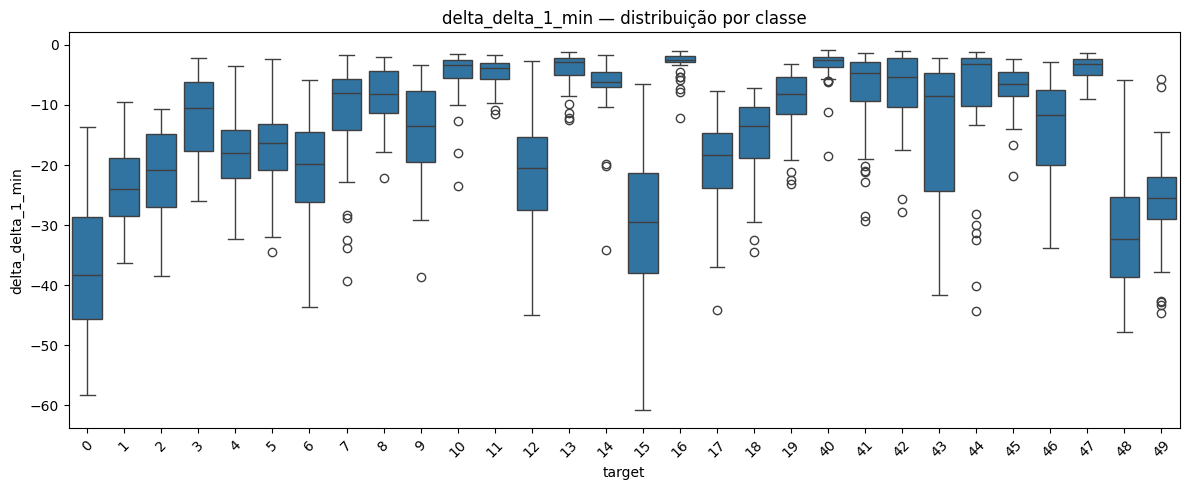

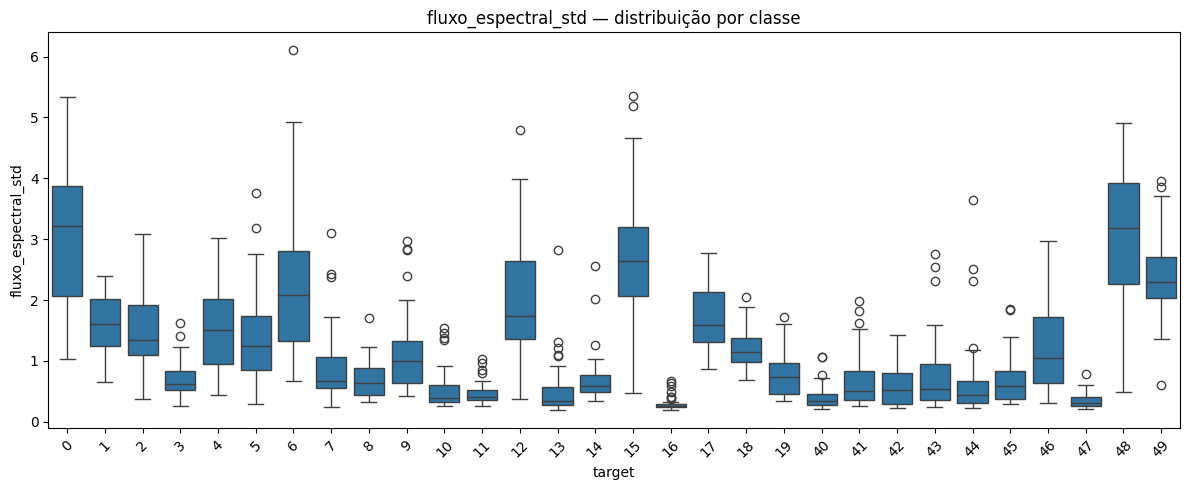

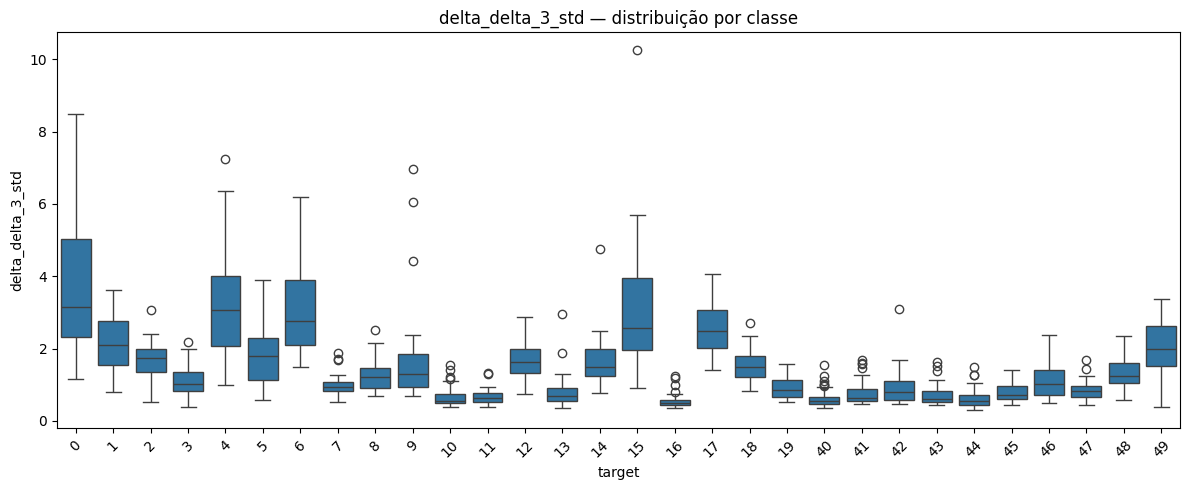

TOP D ---------


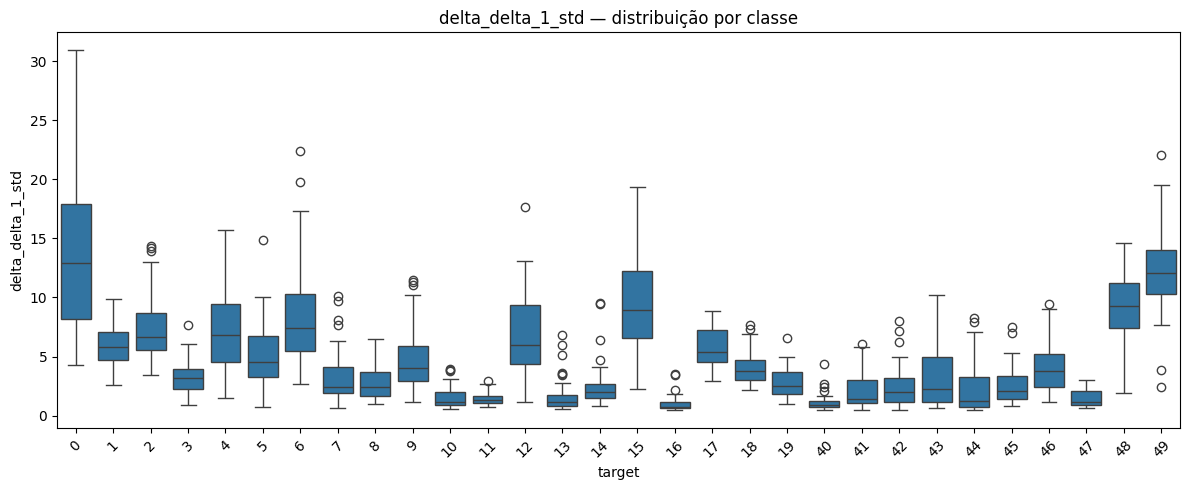

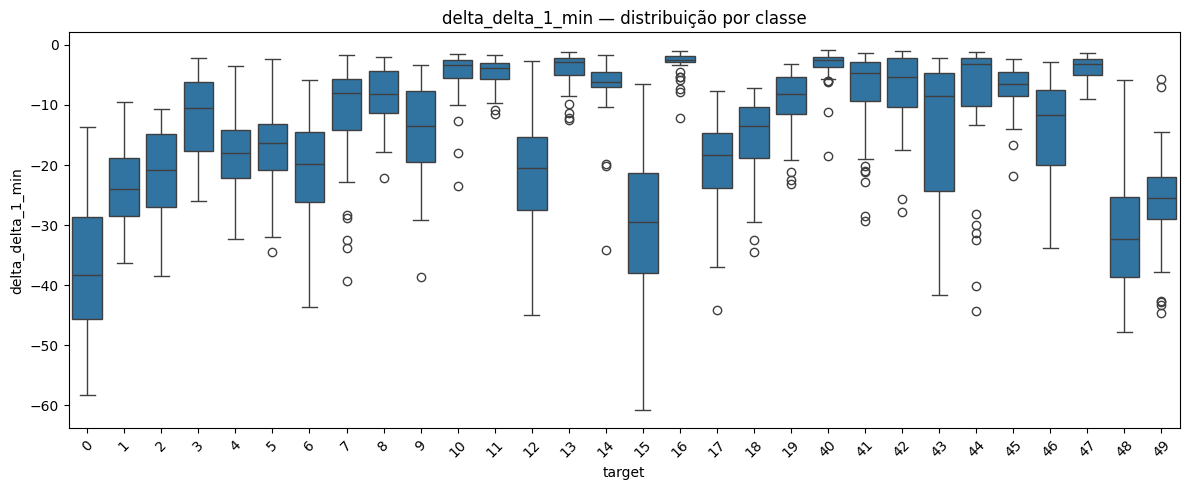

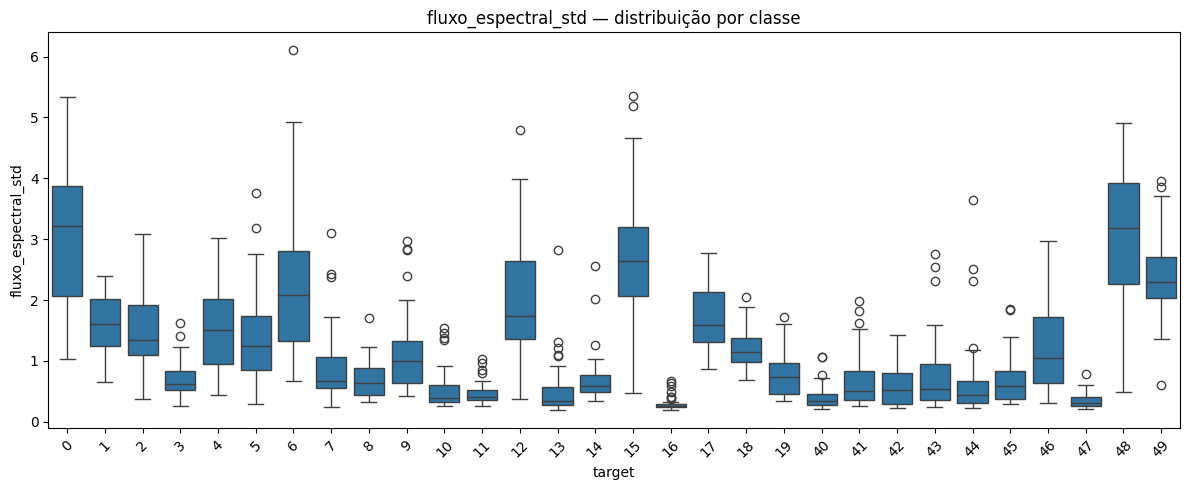

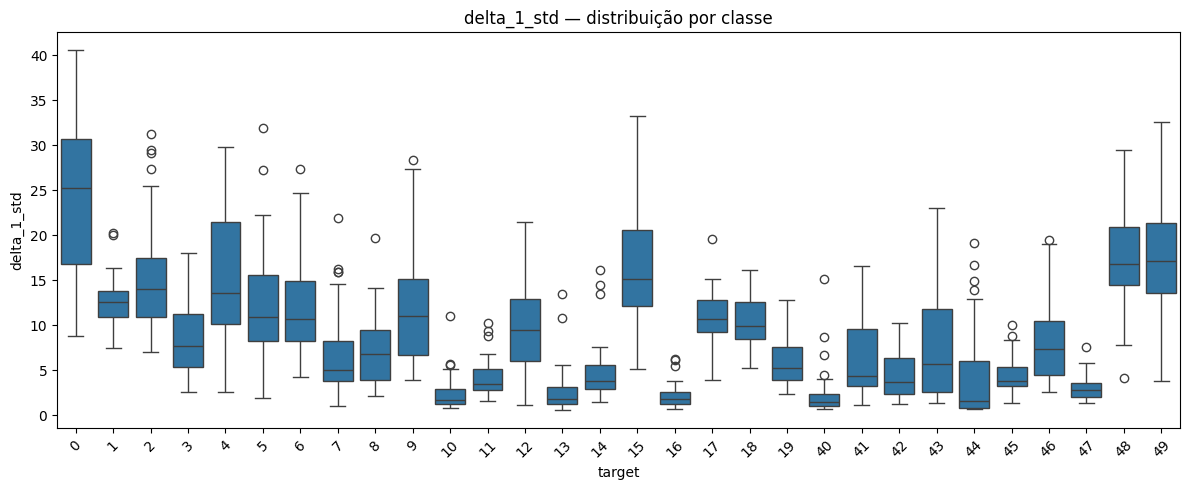

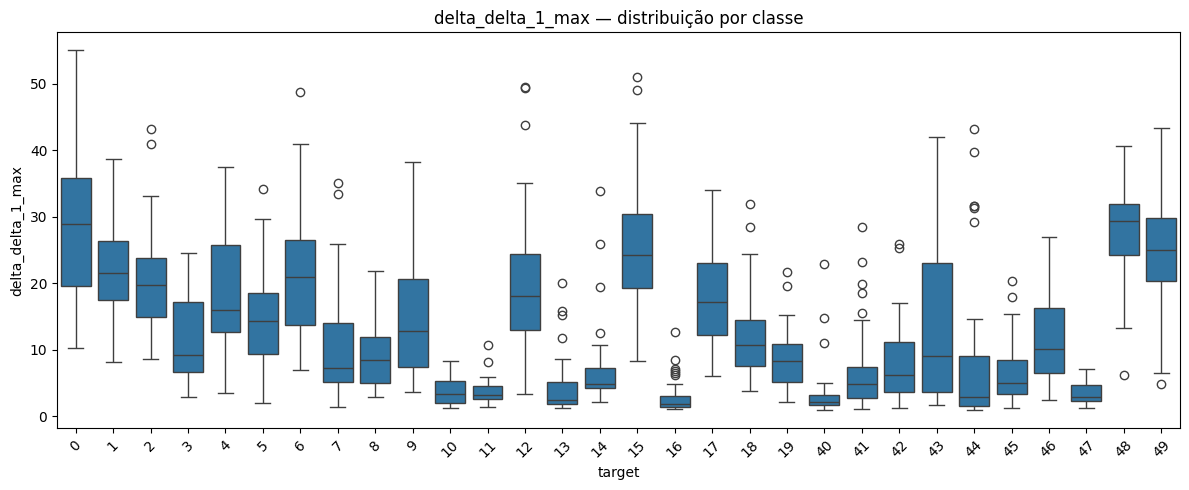

In [21]:
print("TOP A ---------")
visualizar_top_atributos(
    df_A,
    ranking_A,
    n=5
)

print("TOP B ---------")
visualizar_top_atributos(
    df_B,
    ranking_B,
    n=5
)

print("TOP C ---------")
visualizar_top_atributos(
    df_C,
    ranking_C,
    n=5
)

print("TOP D ---------")
visualizar_top_atributos(
    df_D,
    ranking_D,
    n=5
)

### 8. Matriz de Correlação (Pearson) -  Exp C

In [22]:
limiar = 0.80
# Top 30 já ordenados pelo F-score
top_30 = ranking_C.head(30)["atributo"].tolist()

# Correlação dos 30 melhores
matriz_corr = df_C[top_30].corr(method="pearson")
# Começamos com todos os 30
atributos_selecionados = top_30.copy()

# Percorrer os atributos na ordem do F-score
for i in range(len(top_30)):

    atributo_1 = top_30[i]

    # Se já foi removido, pula
    if atributo_1 not in atributos_selecionados:
        continue

    for j in range(i + 1, len(top_30)):
        atributo_2 = top_30[j]

        # Se já foi removido, pula
        if atributo_2 not in atributos_selecionados:
            continue

        correlacao = matriz_corr.loc[atributo_1, atributo_2]

        if abs(correlacao) >= limiar:
            # Como atributo_1 aparece antes no ranking,
            # ele possui F-score maior.
            atributos_selecionados.remove(atributo_2)

print(f"Top 30 inicial: {len(top_30)} atributos")
print(f"Após remover redundâncias: {len(atributos_selecionados)} atributos")

print("\nAtributos finais:")
for i, atributo in enumerate(atributos_selecionados, 1):
    f_score = ranking_C.loc[
        ranking_C["atributo"] == atributo, "F_score"
    ].iloc[0]

    print(f"{i:2d}. {atributo:<40} F Score = {f_score:.2f}")

Top 30 inicial: 30 atributos
Após remover redundâncias: 12 atributos

Atributos finais:
 1. delta_delta_3_max                        F Score = 70.97
 2. delta_delta_1_std                        F Score = 69.05
 3. fluxo_espectral_max                      F Score = 55.08
 4. mfcc_3_std                               F Score = 54.21
 5. delta_1_min                              F Score = 54.03
 6. delta_4_std                              F Score = 54.01
 7. mfcc_3_min                               F Score = 50.44
 8. centroid_max                             F Score = 50.31
 9. delta_delta_2_max                        F Score = 44.95
10. fluxo_espectral_mean                     F Score = 44.43
11. mfcc_1_median                            F Score = 44.04
12. mfcc_5_std                               F Score = 40.43
